In [1]:
%pip install antropy

In [2]:
import os
import warnings
import antropy as ant
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import pearsonr
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    KFold, LeaveOneOut, RandomizedSearchCV,
    StratifiedKFold, cross_val_predict, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

### Merging tables

In [3]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

## Tabela de Resultados

In [4]:
csv_filename = 'eeg_ablation_results_ec.csv'

current_condition = 'Eyes Closed'
current_category = 'Somente Entropia'
classifier_name = 'Linear SVM'

pasta_saida = 'features_extraidas_ec'
nome_arquivo_saida = 'features_entropy.csv' 

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"Tabela já existe. Registros atuais: {len(df_results)}")
else:
    columns = [
        'Feature_Category', 
        'Classifier', 
        'Condition', 
        'Num_Features', 
        'Accuracy', 
        'AUC_ROC', 
        'F1_Score'
    ]
    df_results = pd.DataFrame(columns=columns)
    print("Tabela criada com sucesso.")

Tabela já existe. Registros atuais: 67


In [5]:
bands = {
    'Delta': (0.1, 4),
    'Theta': (4, 8),
    'Low_Alpha': (8, 10),
    'High_Alpha': (10, 13),
    'Low_Beta': (13, 17),
    'High_Beta': (18, 30),
    'Low_Gamma': (30, 50),
    'High_Gamma': (50, 100)
}

X_features = []
y_labels = []
feature_names = []
patient_ids = []
eeg_folder = './cleaned_ec'

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']

### Extração das Features

In [6]:
def compute_apen(data_epochs):
    """Calcula a média do ApEn de todas as epochs com m=3 e r=0.2*std"""
    apen_vals = []
    for ep_idx in range(data_epochs.shape[0]):
        x = data_epochs[ep_idx, :]
        tol = 0.2 * np.std(x)
        ap = ant.app_entropy(x, order=3, metric='chebyshev', tolerance=tol)
        apen_vals.append(ap)
    return np.mean(apen_vals)

In [7]:
for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID'])) 
    pain_score = float(row['Actual Pain']) 

    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_ec-epo.fif")
    
    if os.path.exists(path):
        try:
            epochs = mne.read_epochs(path, preload=True, verbose=False)
            all_channels = epochs.ch_names
            sfreq = epochs.info['sfreq']
            
            epochs_data = epochs.get_data() # (n_epochs, n_channels, n_times)
            
            patient_features = []
            temp_names = [] 
            
            for channel in target_channels:
                if channel in all_channels:
                    i = all_channels.index(channel)
                    channel_epochs = epochs_data[:, i, :] # (n_epochs, n_times)
                    
                    # ApEn Broadband
                    apen_bb = compute_apen(channel_epochs)
                    patient_features.append(apen_bb)
                    if not feature_names: 
                        temp_names.append(f"ApEn_Broadband_{channel}")
                    
                    # ApEn nas Bandas de Frequência
                    for band_name, (fmin, fmax) in bands.items():
                        # Filtragem para isolar a banda
                        filtered_epochs = mne.filter.filter_data(
                            channel_epochs, sfreq, l_freq=fmin, h_freq=fmax, verbose=False
                        )
                        apen_band = compute_apen(filtered_epochs)
                        patient_features.append(apen_band)
                        
                        if not feature_names: 
                            temp_names.append(f"ApEn_{band_name}_{channel}")
                            
                else:
                    # Preenchimento de canais ausentes (1 Broadband + Qtd de Bandas)
                    num_features_per_channel = 1 + len(bands)
                    patient_features.extend([np.nan] * num_features_per_channel)
                    
                    if not feature_names:
                        temp_names.append(f"ApEn_Broadband_{channel}")
                        for band_name in bands.keys():
                            temp_names.append(f"ApEn_{band_name}_{channel}")

            if not feature_names: 
                feature_names = temp_names
            
            X_features.append(patient_features)
            y_labels.append(pain_score)
            patient_ids.append(patient_id)
            print(f"Processamento do paciente {patient_id} finalizado.")
            
        except Exception as e:
            print(f"Falha no paciente {patient_id}: {e}")

X = np.array(X_features)
y = np.array(y_labels)

# Remove colunas que contenham apenas valores NaN (canais faltando em todos os pacientes)
valid_columns = ~np.isnan(X).all(axis=0)
X = X[:, valid_columns]
feature_names = np.array(feature_names)[valid_columns]

print("\n - EXTRAÇÃO CONCLUÍDA - ")
print(f"Formato Final da Matriz (X): {X.shape}")
print(f"Total de Biomarcadores Válidos: {len(feature_names)}")

# DataFrame com as features
df_features = pd.DataFrame(X, columns=feature_names)
df_features['patient_id'] = patient_ids
df_features['pain_score'] = y

os.makedirs(pasta_saida, exist_ok=True)
caminho_arquivo_saida = os.path.join(pasta_saida, nome_arquivo_saida)
df_features.to_csv(caminho_arquivo_saida, index=False)


Processamento do paciente 0 finalizado.
Processamento do paciente 1 finalizado.
Processamento do paciente 2 finalizado.
Processamento do paciente 3 finalizado.
Processamento do paciente 4 finalizado.
Processamento do paciente 5 finalizado.
Processamento do paciente 6 finalizado.
Processamento do paciente 7 finalizado.
Processamento do paciente 8 finalizado.
Processamento do paciente 9 finalizado.
Processamento do paciente 10 finalizado.
Processamento do paciente 11 finalizado.
Processamento do paciente 13 finalizado.
Processamento do paciente 15 finalizado.
Processamento do paciente 16 finalizado.
Processamento do paciente 18 finalizado.
Processamento do paciente 19 finalizado.
Processamento do paciente 20 finalizado.
Processamento do paciente 21 finalizado.
Processamento do paciente 22 finalizado.
Processamento do paciente 23 finalizado.
Processamento do paciente 24 finalizado.
Processamento do paciente 25 finalizado.
Processamento do paciente 26 finalizado.
Processamento do paciente 

### Treinamento SVM (LOO)


Avaliando Linear SVM (Somente Entropia) — class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 51.4%
LOO AUC-ROC: 0.484

Melhores hiperparâmetros: {'svm_final__C': 0.01}
-------------------------------------------------------

TOP 5 BIOMARCADORES (Linear SVM):
  1. ApEn_High_Gamma_F4: 2.2% de importância
  2. ApEn_Broadband_Pz: 2.0% de importância
  3. ApEn_High_Gamma_P7: 2.0% de importância
  4. ApEn_High_Gamma_P8: 1.9% de importância
  5. ApEn_Broadband_F7: 1.9% de importância


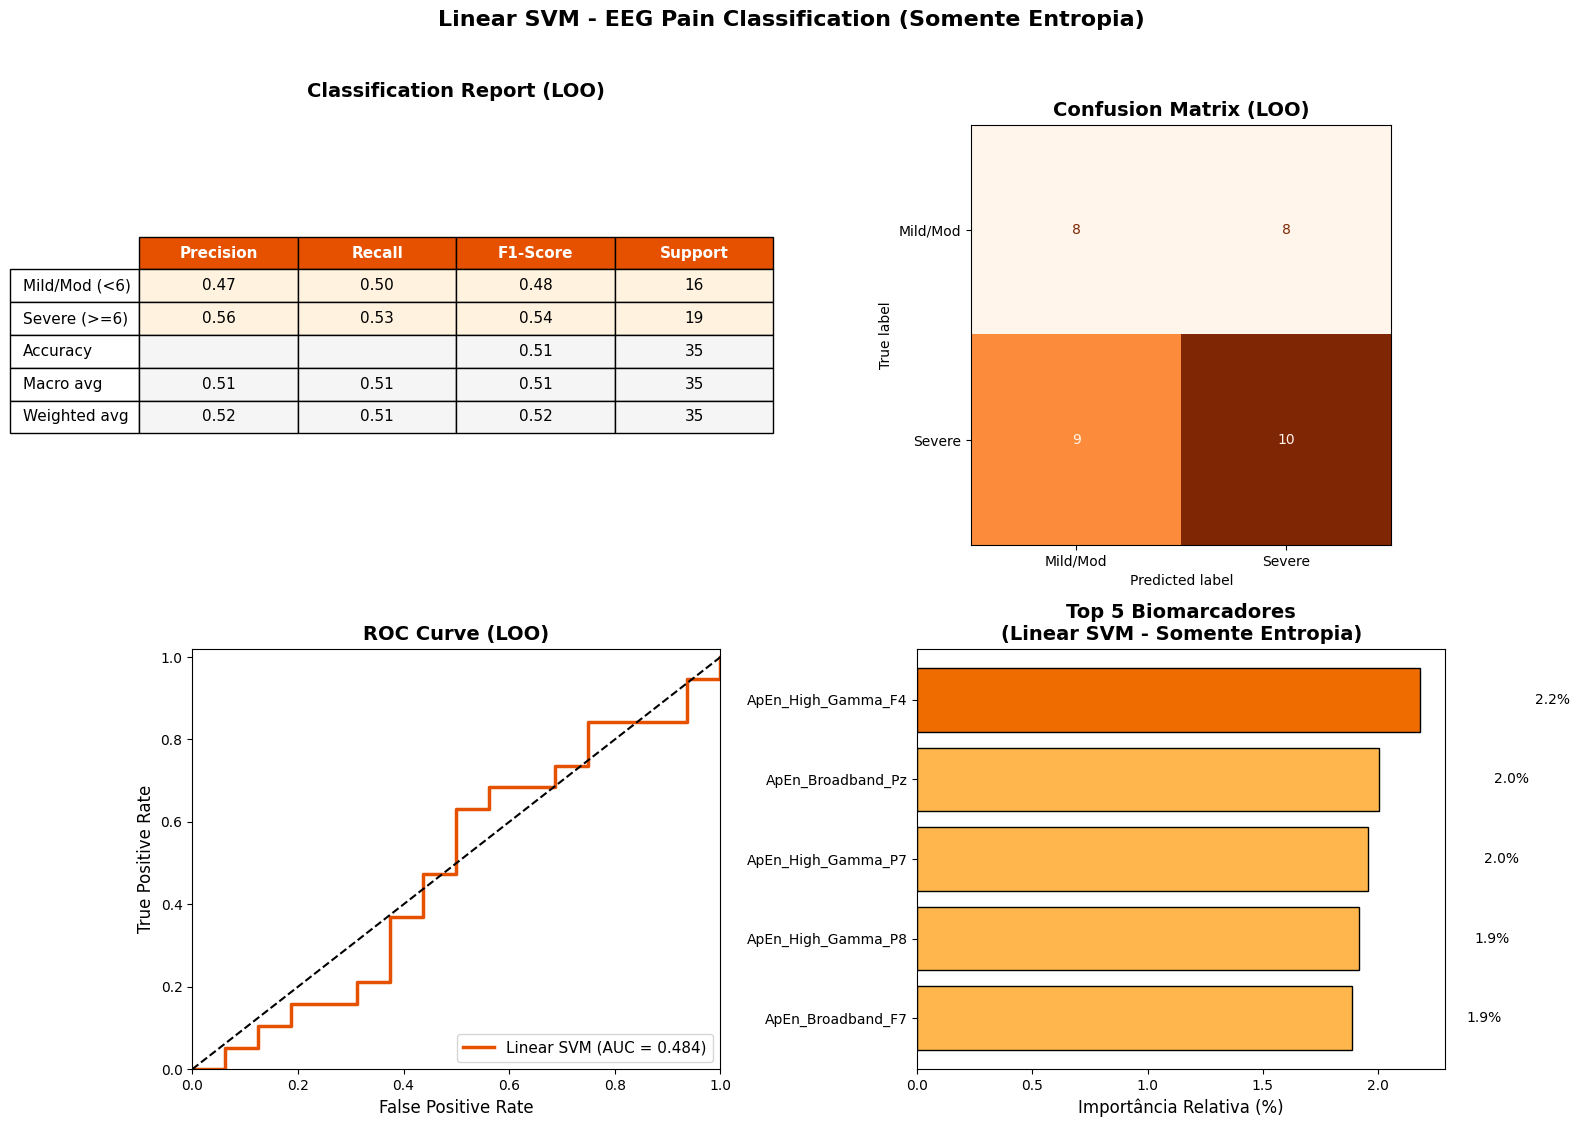


Gráfico salvo como: images\05_svm_entropy_ec_results.png
Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [8]:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando {classifier_name} ({current_category}) — class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_top_features = 5 # Número de features para exibir no gráfico de barras

    # Pipeline base com SVM Linear
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    acc_loo = scores_acc.mean()

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treinar no dataset completo para revelar a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nMelhores hiperparâmetros: {search.best_params_}")

    # Extração de Importância das Features
    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_top_features} BIOMARCADORES ({classifier_name}):")
    for i, idx in enumerate(ranking[:num_top_features], 1):
        print(f"  {i}. {feature_names_filt[idx]}: {importances_pct[idx]:.1f}% de importância")

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data, 
        rowLabels=row_labels, 
        colLabels=col_labels, 
        cellLoc='center', 
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'{classifier_name} (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    top_indices = ranking[:num_top_features]
    bios_ordered  = feature_names_filt[top_indices]
    scores_ordered = importances_pct[top_indices]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_top_features} Biomarcadores\n({classifier_name} - {current_category})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'{classifier_name} - EEG Pain Classification ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '05_svm_entropy_ec_results.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1],
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"Resultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")


Avaliando SVM Multiclasse (3 Níveis) (Somente Entropia) - OverSampling + RFE + LOO
Leve (0-3): 10 pacientes
Moderada (4-6): 11 pacientes
Intensa (7-10): 14 pacientes


Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 45.7%
LOO AUC-ROC (Weighted): 0.603
-------------------------------------------------------

TOP 5 BIOMARCADORES ENTROPIA (Linear SVM RFE - 3 Níveis):
  1. ApEn_Delta_Pz: 22.8% de importância
  2. ApEn_High_Beta_P4: 21.3% de importância
  3. ApEn_Low_Gamma_F8: 21.0% de importância
  4. ApEn_Delta_P4: 18.5% de importância
  5. ApEn_Theta_F7: 16.4% de importância


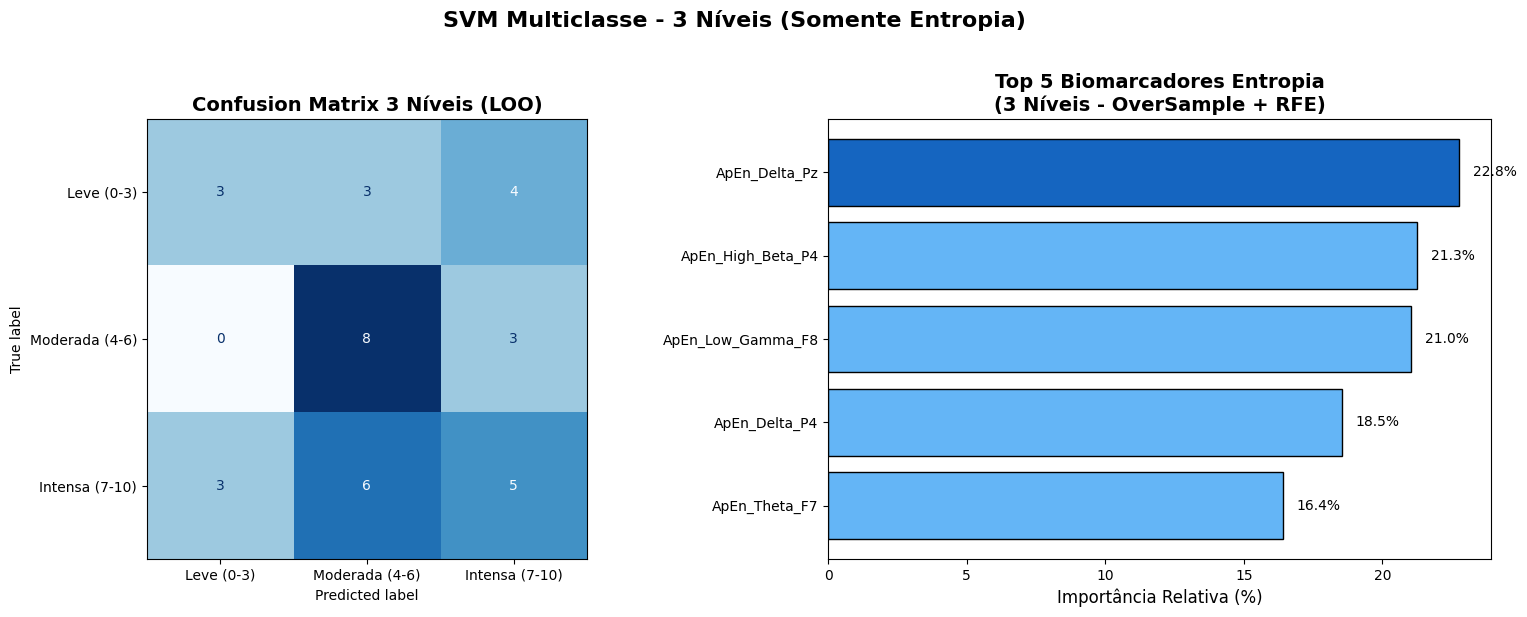


Gráfico salvo como: images\05_svm_3_levels_entropy(+rfe_oversampling)_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [9]:
# PIPELINE (ENTROPIA) COM OVERSAMPLING + RFE + SVM MULTICLASSE (3 NÍVEIS)
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando SVM Multiclasse (3 Níveis) ({current_category}) - OverSampling + RFE + LOO")
    print('=' * 60)

    # Função de mapeamento para 3 níveis de dor
    def map_pain_3_levels(score):
        if score <= 3: return 0     # Leve (0 a 3)
        elif score <= 6: return 1   # Moderada (4 a 6)
        else: return 2              # Intensa (7 a 10)

    y_class_3_levels = np.array([map_pain_3_levels(s) for s in y])
    
    classes_names_3 = ['Leve (0-3)', 'Moderada (4-6)', 'Intensa (7-10)']
    for i, c_name in enumerate(classes_names_3):
        print(f"{c_name}: {sum(y_class_3_levels==i)} pacientes")
    print("\n")

    # Filtro de canais (caso exista M1/M2)
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    num_k_3 = 5 
    
    # Motor de extração do RFE e classificador final multiclasse (OvR nativo)
    svm_linear_3 = SVC(kernel='linear', random_state=42, class_weight='balanced', probability=True)
    selector_rfe_3 = RFE(estimator=svm_linear_3, n_features_to_select=num_k_3, step=2)

    # RandomOverSampler para balancear as classes no treino
    oversampler_3 = RandomOverSampler(random_state=42)

    base_pipeline_3 = ImbPipeline([
        ('scaler', StandardScaler()),
        ('oversample', oversampler_3),
        ('rfe', selector_rfe_3),
        ('svm_final', svm_linear_3)
    ])

    param_dist_3 = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    # KFold no inner loop (evita erro em classes minoritárias) e LeaveOneOut no outer loop
    inner_cv_3 = KFold(n_splits=3, shuffle=True, random_state=42) 
    outer_cv_3 = LeaveOneOut()

    search_3 = RandomizedSearchCV(
        base_pipeline_3, param_dist_3,
        n_iter=8, cv=inner_cv_3, scoring='accuracy', 
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    y_pred_3 = cross_val_predict(search_3, X_filtered, y_class_3_levels, cv=outer_cv_3)
    y_proba_3 = cross_val_predict(search_3, X_filtered, y_class_3_levels, cv=outer_cv_3, method='predict_proba')
    
    acc_loo_3 = np.mean(y_pred_3 == y_class_3_levels)
    try:
        auc_loo_3 = roc_auc_score(y_class_3_levels, y_proba_3, multi_class='ovr', average='weighted')
    except ValueError:
        auc_loo_3 = 0.0 
    f1_macro_3 = f1_score(y_class_3_levels, y_pred_3, average='macro')

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo_3*100:.1f}%")
    print(f"LOO AUC-ROC (Weighted): {auc_loo_3:.3f}")

    # Ajuste no dataset inteiro para extrair as features mais importantes
    search_3.fit(X_filtered, y_class_3_levels)
    
    mask_3 = search_3.best_estimator_.named_steps['rfe'].get_support()
    biomarkers_3 = feature_names_filt[mask_3]
    
    # Extraindo pesos multiclasse (média dos absolutos para rankear a importância geral)
    coef_originais_3 = search_3.best_estimator_.named_steps['rfe'].estimator_.coef_
    importances_3 = np.mean(np.abs(coef_originais_3), axis=0)
    importances_pct_3 = importances_3 / importances_3.sum() * 100
    ranking_3 = np.argsort(importances_pct_3)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k_3} BIOMARCADORES ENTROPIA (Linear SVM RFE - 3 Níveis):")
    for i, idx in enumerate(ranking_3, 1):
        print(f"  {i}. {biomarkers_3[idx]}: {importances_pct_3[idx]:.1f}% de importância")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax_cm, ax_feat = axes[0], axes[1]

    # Confusion Matrix
    cm_3 = confusion_matrix(y_class_3_levels, y_pred_3)
    present_classes_3 = np.unique(np.concatenate([y_class_3_levels, y_pred_3]))
    disp_labels_3 = [classes_names_3[i] for i in present_classes_3]
    
    disp = ConfusionMatrixDisplay(cm_3, display_labels=disp_labels_3)
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues', xticks_rotation=0)
    ax_cm.set_title('Confusion Matrix 3 Níveis (LOO)', fontsize=14, fontweight='bold')

    # Gráfico de Barras - Importância das Features
    bios_ordered_3  = biomarkers_3[ranking_3]
    scores_ordered_3 = importances_pct_3[ranking_3]
    
    colors_3 = ['#1565c0' if s == scores_ordered_3.max() else '#64b5f6' for s in scores_ordered_3]
    bars = ax_feat.barh(range(len(bios_ordered_3)), scores_ordered_3[::-1], color=colors_3[::-1], edgecolor='black')
    ax_feat.set_yticks(range(len(bios_ordered_3)))
    ax_feat.set_yticklabels(bios_ordered_3[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k_3} Biomarcadores Entropia\n(3 Níveis - OverSample + RFE)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered_3[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'SVM Multiclasse - 3 Níveis ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    if 'save_folder' not in locals():
        save_folder = 'images'
        os.makedirs(save_folder, exist_ok=True)
        
    save_path_3 = os.path.join(save_folder, '05_svm_3_levels_entropy(+rfe_oversampling)_results.png') 
    plt.savefig(save_path_3, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path_3}")

    # Atualizar o CSV
    if os.path.exists(csv_filename):
        df_results = pd.read_csv(csv_filename)
    else:
        df_results = pd.DataFrame()

    new_result_3 = pd.DataFrame([{
        'Feature_Category': current_category + ' + RFE + OverSample (3 Níveis)',
        'Classifier': 'SVM 3 Níveis',
        'Condition': current_condition,
        'Num_Features': num_k_3,
        'Accuracy': round(acc_loo_3, 4),
        'AUC_ROC': round(auc_loo_3, 4),
        'F1_Score': round(f1_macro_3, 4)
    }])
    
    df_results = pd.concat([df_results, new_result_3], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")


Avaliando SVM Multiclasse (3 Níveis) (Somente Entropia) - OverSampling + LOO (Sem RFE)
Leve (0-3): 10 pacientes
Moderada (4-6): 11 pacientes
Intensa (7-10): 14 pacientes


Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 20.0%
LOO AUC-ROC (Weighted): 0.416
-------------------------------------------------------

TOP 5 BIOMARCADORES ENTROPIA (Linear SVM - 3 Níveis):
  1. ApEn_Low_Gamma_F8: 1.5% de importância
  2. ApEn_Low_Beta_P4: 1.4% de importância
  3. ApEn_Low_Beta_Pz: 1.3% de importância
  4. ApEn_Low_Gamma_Cz: 1.3% de importância
  5. ApEn_Low_Gamma_C4: 1.2% de importância


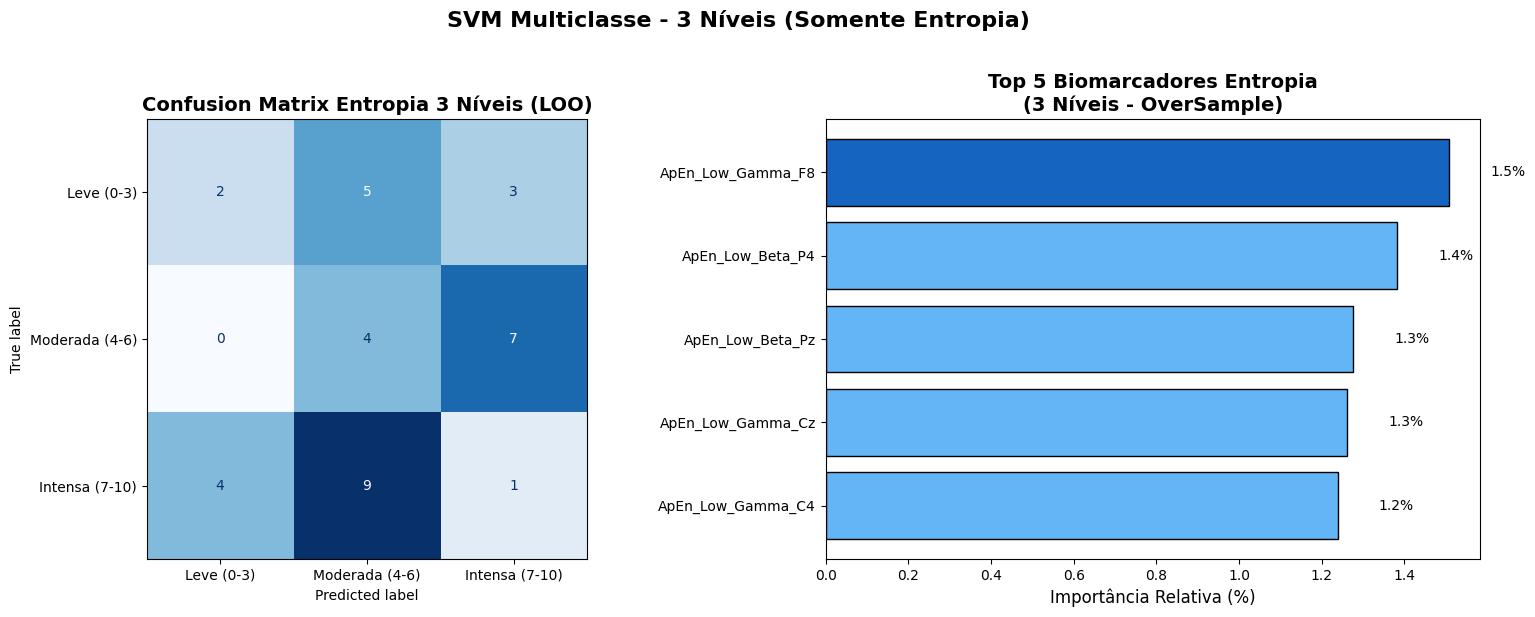


Gráfico salvo como: images\05_svm_3_levels_entropy(+oversampling)_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [10]:
# PIPELINE (ENTROPIA) COM OVERSAMPLING + SVM MULTICLASSE (3 NÍVEIS) - SEM RFE
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando SVM Multiclasse (3 Níveis) ({current_category}) - OverSampling + LOO (Sem RFE)")
    print('=' * 60)

    # Função de mapeamento para 3 níveis de dor
    def map_pain_3_levels(score):
        if score <= 3: return 0     # Leve (0 a 3)
        elif score <= 6: return 1   # Moderada (4 a 6)
        else: return 2              # Intensa (7 a 10)

    y_class_3_levels = np.array([map_pain_3_levels(s) for s in y])
    
    classes_names_3 = ['Leve (0-3)', 'Moderada (4-6)', 'Intensa (7-10)']
    for i, c_name in enumerate(classes_names_3):
        print(f"{c_name}: {sum(y_class_3_levels==i)} pacientes")
    print("\n")

    # Filtro de canais (caso exista M1/M2)
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    num_k_3 = 5 # Quantidade de features para exibir no Top N do gráfico
    
    # Classificador final multiclasse (OvR nativo)
    svm_linear_3 = SVC(kernel='linear', random_state=42, class_weight='balanced', probability=True)

    # RandomOverSampler para balancear as classes no treino
    oversampler_3 = RandomOverSampler(random_state=42)

    # Pipeline da biblioteca imblearn (sem a etapa de RFE)
    base_pipeline_3 = ImbPipeline([
        ('scaler', StandardScaler()),
        ('oversample', oversampler_3),
        ('svm_final', svm_linear_3)
    ])

    param_dist_3 = {
        'svm_final__C': [0.001, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    # KFold no inner loop e LeaveOneOut no outer loop
    inner_cv_3 = KFold(n_splits=3, shuffle=True, random_state=42) 
    outer_cv_3 = LeaveOneOut()

    search_3 = RandomizedSearchCV(
        base_pipeline_3, param_dist_3,
        n_iter=6, cv=inner_cv_3, scoring='accuracy', 
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    y_pred_3 = cross_val_predict(search_3, X_filtered, y_class_3_levels, cv=outer_cv_3)
    y_proba_3 = cross_val_predict(search_3, X_filtered, y_class_3_levels, cv=outer_cv_3, method='predict_proba')
    
    acc_loo_3 = np.mean(y_pred_3 == y_class_3_levels)
    try:
        auc_loo_3 = roc_auc_score(y_class_3_levels, y_proba_3, multi_class='ovr', average='weighted')
    except ValueError:
        auc_loo_3 = 0.0 
    f1_macro_3 = f1_score(y_class_3_levels, y_pred_3, average='macro')

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo_3*100:.1f}%")
    print(f"LOO AUC-ROC (Weighted): {auc_loo_3:.3f}")

    # Ajuste no dataset inteiro para extrair as features mais importantes
    search_3.fit(X_filtered, y_class_3_levels)
    
    # Sem RFE, usamos todos os biomarcadores filtrados
    biomarkers_3 = feature_names_filt
    
    # Extraindo pesos multiclasse diretamente da camada do SVM (média dos absolutos para rankear a importância geral)
    coef_originais_3 = search_3.best_estimator_.named_steps['svm_final'].coef_
    importances_3 = np.mean(np.abs(coef_originais_3), axis=0)
    importances_pct_3 = importances_3 / importances_3.sum() * 100
    
    # Organiza o ranking e filtra apenas o Top K para exibição no gráfico
    ranking_3 = np.argsort(importances_pct_3)[::-1]
    top_k_indices = ranking_3[:num_k_3]
    
    print('-' * 55)
    print(f"\nTOP {num_k_3} BIOMARCADORES ENTROPIA (Linear SVM - 3 Níveis):")
    for i, idx in enumerate(top_k_indices, 1):
        print(f"  {i}. {biomarkers_3[idx]}: {importances_pct_3[idx]:.1f}% de importância")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax_cm, ax_feat = axes[0], axes[1]

    # Confusion Matrix
    cm_3 = confusion_matrix(y_class_3_levels, y_pred_3)
    present_classes_3 = np.unique(np.concatenate([y_class_3_levels, y_pred_3]))
    disp_labels_3 = [classes_names_3[i] for i in present_classes_3]
    
    disp = ConfusionMatrixDisplay(cm_3, display_labels=disp_labels_3)
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues', xticks_rotation=0)
    ax_cm.set_title('Confusion Matrix Entropia 3 Níveis (LOO)', fontsize=14, fontweight='bold')

    # Gráfico de Barras - Importância das Features
    bios_ordered_3  = biomarkers_3[top_k_indices]
    scores_ordered_3 = importances_pct_3[top_k_indices]
    
    colors_3 = ['#1565c0' if s == scores_ordered_3.max() else '#64b5f6' for s in scores_ordered_3]
    bars = ax_feat.barh(range(len(bios_ordered_3)), scores_ordered_3[::-1], color=colors_3[::-1], edgecolor='black')
    ax_feat.set_yticks(range(len(bios_ordered_3)))
    ax_feat.set_yticklabels(bios_ordered_3[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k_3} Biomarcadores Entropia\n(3 Níveis - OverSample)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered_3[::-1]):
        ax_feat.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'SVM Multiclasse - 3 Níveis ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    if 'save_folder' not in locals():
        save_folder = 'images'
        os.makedirs(save_folder, exist_ok=True)
        
    save_path_3 = os.path.join(save_folder, '05_svm_3_levels_entropy(+oversampling)_results.png') 
    plt.savefig(save_path_3, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path_3}")

    if os.path.exists(csv_filename):
        df_results = pd.read_csv(csv_filename)
    else:
        df_results = pd.DataFrame()

    new_result_3 = pd.DataFrame([{
        'Feature_Category': current_category + ' + OverSample (3 Níveis)',
        'Classifier': 'SVM 3 Níveis',
        'Condition': current_condition,
        'Num_Features': X_filtered.shape[1], # Registrando que o RFE não foi utilizado e todas as features entraram no modelo
        'Accuracy': round(acc_loo_3, 4),
        'AUC_ROC': round(auc_loo_3, 4),
        'F1_Score': round(f1_macro_3, 4)
    }])
    
    df_results = pd.concat([df_results, new_result_3], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")


Avaliando SVM Multiclasse (3 Níveis) (Somente Entropia) - RFE + LOO (Sem OverSampling)
Leve (0-3): 10 pacientes
Moderada (4-6): 11 pacientes
Intensa (7-10): 14 pacientes


Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 37.1%
LOO AUC-ROC (Weighted): 0.515
-------------------------------------------------------

TOP 5 BIOMARCADORES ENTROPIA (Linear SVM RFE - 3 Níveis):
  1. ApEn_Low_Beta_P4: 25.7% de importância
  2. ApEn_Low_Gamma_F8: 22.2% de importância
  3. ApEn_High_Beta_P4: 20.8% de importância
  4. ApEn_Theta_F7: 19.5% de importância
  5. ApEn_Delta_Pz: 11.8% de importância


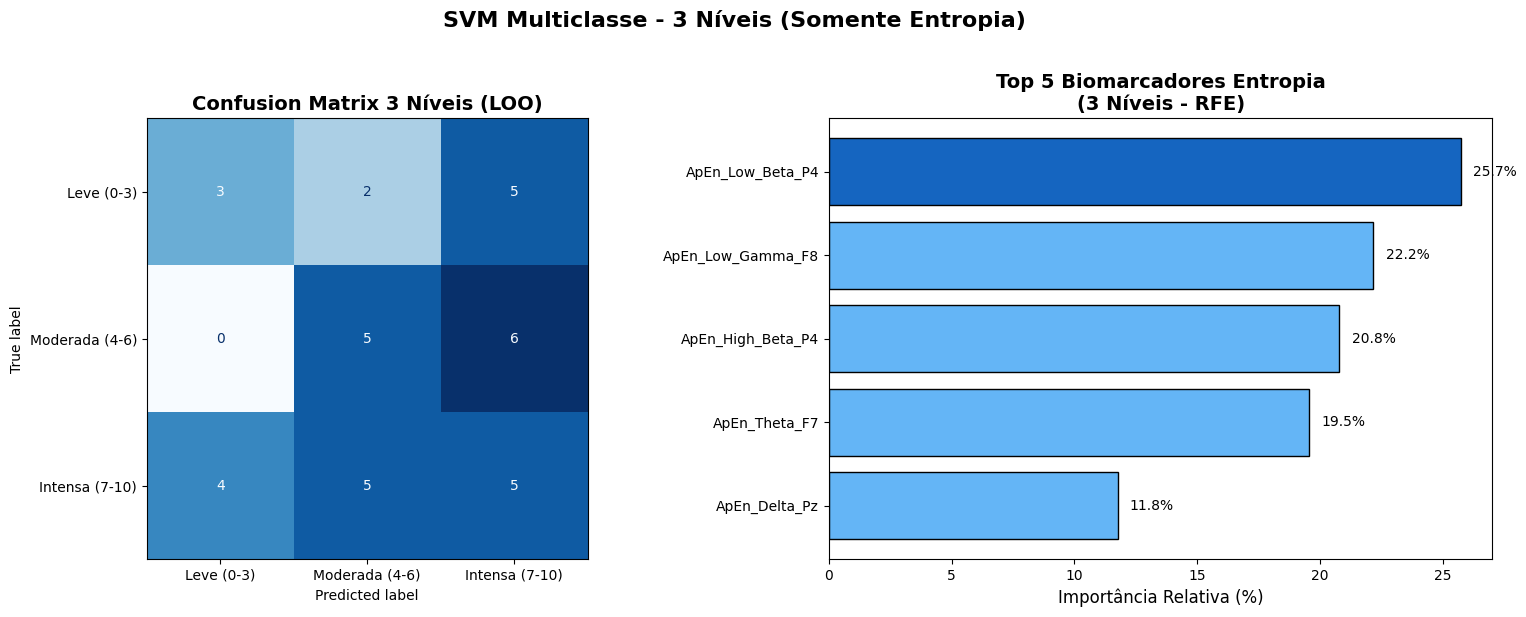


Gráfico salvo como: images\05_svm_3_levels_entropy(+rfe)_results.png

Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [11]:
# PIPELINE (ENTROPIA) COM RFE + SVM MULTICLASSE (3 NÍVEIS) - SEM OVERSAMPLING
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando SVM Multiclasse (3 Níveis) ({current_category}) - RFE + LOO (Sem OverSampling)")
    print('=' * 60)

    # Função de mapeamento para 3 níveis de dor
    def map_pain_3_levels(score):
        if score <= 3: return 0     # Leve (0 a 3)
        elif score <= 6: return 1   # Moderada (4 a 6)
        else: return 2              # Intensa (7 a 10)

    y_class_3_levels = np.array([map_pain_3_levels(s) for s in y])
    
    classes_names_3 = ['Leve (0-3)', 'Moderada (4-6)', 'Intensa (7-10)']
    for i, c_name in enumerate(classes_names_3):
        print(f"{c_name}: {sum(y_class_3_levels==i)} pacientes")
    print("\n")

    # Filtro de canais (caso exista M1/M2)
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    num_k_3 = 5 
    
    # Motor de extração do RFE e classificador final multiclasse (OvR nativo)
    svm_linear_3 = SVC(kernel='linear', random_state=42, class_weight='balanced', probability=True)
    selector_rfe_3 = RFE(estimator=svm_linear_3, n_features_to_select=num_k_3, step=2)

    # Pipeline padrão do scikit-learn (Sem OverSampling)
    base_pipeline_3 = Pipeline([
        ('scaler', StandardScaler()),
        ('rfe', selector_rfe_3),
        ('svm_final', svm_linear_3)
    ])

    param_dist_3 = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    # KFold no inner loop e LeaveOneOut no outer loop
    inner_cv_3 = KFold(n_splits=3, shuffle=True, random_state=42) 
    outer_cv_3 = LeaveOneOut()

    search_3 = RandomizedSearchCV(
        base_pipeline_3, param_dist_3,
        n_iter=8, cv=inner_cv_3, scoring='accuracy', 
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    y_pred_3 = cross_val_predict(search_3, X_filtered, y_class_3_levels, cv=outer_cv_3)
    y_proba_3 = cross_val_predict(search_3, X_filtered, y_class_3_levels, cv=outer_cv_3, method='predict_proba')
    
    acc_loo_3 = np.mean(y_pred_3 == y_class_3_levels)
    try:
        auc_loo_3 = roc_auc_score(y_class_3_levels, y_proba_3, multi_class='ovr', average='weighted')
    except ValueError:
        auc_loo_3 = 0.0 
    f1_macro_3 = f1_score(y_class_3_levels, y_pred_3, average='macro')

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo_3*100:.1f}%")
    print(f"LOO AUC-ROC (Weighted): {auc_loo_3:.3f}")

    # Ajuste no dataset inteiro para extrair as features mais importantes
    search_3.fit(X_filtered, y_class_3_levels)
    
    mask_3 = search_3.best_estimator_.named_steps['rfe'].get_support()
    biomarkers_3 = feature_names_filt[mask_3]
    
    # Extraindo pesos multiclasse (média dos absolutos para rankear a importância geral)
    coef_originais_3 = search_3.best_estimator_.named_steps['rfe'].estimator_.coef_
    importances_3 = np.mean(np.abs(coef_originais_3), axis=0)
    importances_pct_3 = importances_3 / importances_3.sum() * 100
    ranking_3 = np.argsort(importances_pct_3)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k_3} BIOMARCADORES ENTROPIA (Linear SVM RFE - 3 Níveis):")
    for i, idx in enumerate(ranking_3, 1):
        print(f"  {i}. {biomarkers_3[idx]}: {importances_pct_3[idx]:.1f}% de importância")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax_cm, ax_feat = axes[0], axes[1]

    # Confusion Matrix
    cm_3 = confusion_matrix(y_class_3_levels, y_pred_3)
    present_classes_3 = np.unique(np.concatenate([y_class_3_levels, y_pred_3]))
    disp_labels_3 = [classes_names_3[i] for i in present_classes_3]
    
    disp = ConfusionMatrixDisplay(cm_3, display_labels=disp_labels_3)
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues', xticks_rotation=0)
    ax_cm.set_title('Confusion Matrix 3 Níveis (LOO)', fontsize=14, fontweight='bold')

    # Gráfico de Barras - Importância das Features
    bios_ordered_3  = biomarkers_3[ranking_3]
    scores_ordered_3 = importances_pct_3[ranking_3]
    
    colors_3 = ['#1565c0' if s == scores_ordered_3.max() else '#64b5f6' for s in scores_ordered_3]
    bars = ax_feat.barh(range(len(bios_ordered_3)), scores_ordered_3[::-1], color=colors_3[::-1], edgecolor='black')
    ax_feat.set_yticks(range(len(bios_ordered_3)))
    ax_feat.set_yticklabels(bios_ordered_3[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k_3} Biomarcadores Entropia\n(3 Níveis - RFE)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered_3[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'SVM Multiclasse - 3 Níveis ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    if 'save_folder' not in locals():
        save_folder = 'images'
        os.makedirs(save_folder, exist_ok=True)
        
    save_path_3 = os.path.join(save_folder, '05_svm_3_levels_entropy(+rfe)_results.png') 
    plt.savefig(save_path_3, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico salvo como: {save_path_3}")

    # Atualizar o CSV
    if os.path.exists(csv_filename):
        df_results = pd.read_csv(csv_filename)
    else:
        df_results = pd.DataFrame()

    new_result_3 = pd.DataFrame([{
        'Feature_Category': current_category + ' + RFE (3 Níveis)',
        'Classifier': 'SVM 3 Níveis',
        'Condition': current_condition,
        'Num_Features': num_k_3,
        'Accuracy': round(acc_loo_3, 4),
        'AUC_ROC': round(auc_loo_3, 4),
        'F1_Score': round(f1_macro_3, 4)
    }])
    
    df_results = pd.concat([df_results, new_result_3], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")


Avaliando Multi-SVM Hierárquico (Somente Entropia) - OverSampling + RFE + LOO
Sem Dor (0): 2 pacientes
Leve (1-3): 8 pacientes
Média (4-5): 6 pacientes
Alta (6-7): 11 pacientes
Intolerável (8-10): 8 pacientes


Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 40.0%
LOO AUC-ROC (Weighted): 0.611
-------------------------------------------------------

TOP 5 BIOMARCADORES (Linear SVM RFE):
  1. ApEn_High_Alpha_P4: 29.3% de importância
  2. ApEn_Delta_T8: 26.4% de importância
  3. ApEn_Delta_O1: 18.2% de importância
  4. ApEn_Low_Gamma_F8: 14.7% de importância
  5. ApEn_Delta_P3: 11.3% de importância


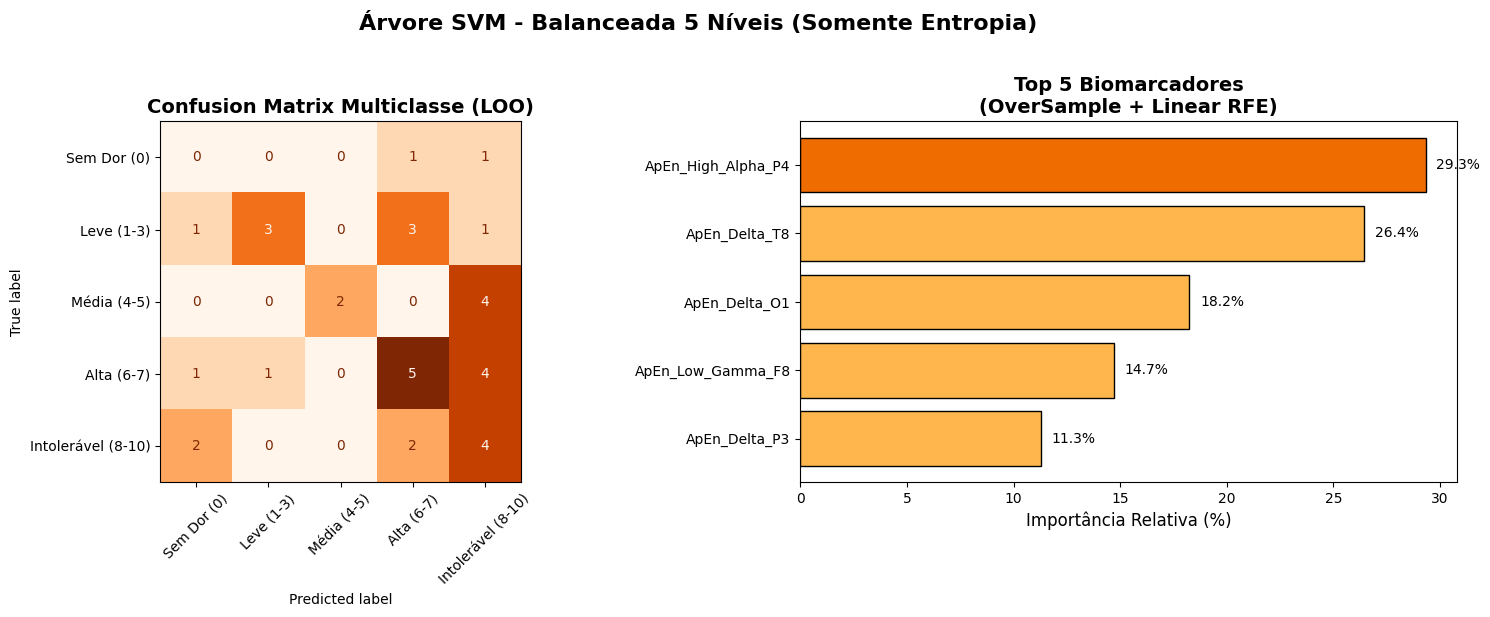


Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [12]:
# CLASSE DO MODELO: Árvore de Decisão Hierárquica (Multi-SVM)

class HierarchicalPainSVM(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, gamma='scale'):
        self.C = C
        self.gamma = gamma
        self.node1 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node2 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node3 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node4 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        y = np.array(y)
        
        y1 = np.where(y == 0, 0, 1)
        self.node1.fit(X, y1)
        
        mask2 = (y != 0)
        if np.any(mask2):
            y2 = np.where(y[mask2] == 4, 1, 0)
            self.node2.fit(X[mask2], y2)
            
        mask3 = (y != 0) & (y != 4)
        if np.any(mask3):
            y3 = np.where(y[mask3] == 3, 1, 0)
            self.node3.fit(X[mask3], y3)
            
        mask4 = (y == 1) | (y == 2)
        if np.any(mask4):
            y4 = np.where(y[mask4] == 2, 1, 0)
            self.node4.fit(X[mask4], y4)
            
        return self

    def predict(self, X):
        predictions = []
        for x_i in X:
            x_in = x_i.reshape(1, -1)
            if self.node1.predict(x_in)[0] == 0:
                predictions.append(0)
            elif self.node2.predict(x_in)[0] == 1:
                predictions.append(4)
            elif self.node3.predict(x_in)[0] == 1:
                predictions.append(3)
            elif self.node4.predict(x_in)[0] == 1:
                predictions.append(2)
            else:
                predictions.append(1)
        return np.array(predictions)
        
    def predict_proba(self, X):
        proba = np.zeros((X.shape[0], 5))
        for i, x_i in enumerate(X):
            pred = self.predict(x_i.reshape(1, -1))[0]
            proba[i, pred] = 1.0 
        return proba


# PIPELINE COM OVERSAMPLING + RFE + HIERARCHICAL SVM
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando Multi-SVM Hierárquico ({current_category}) - OverSampling + RFE + LOO")
    print('=' * 60)

    def map_pain_5_levels(score):
        if score == 0: return 0           
        elif score <= 3: return 1         
        elif score <= 5: return 2         
        elif score <= 7: return 3         
        else: return 4                    

    y_class_hierarchical = np.array([map_pain_5_levels(s) for s in y])
    
    classes_names = ['Sem Dor (0)', 'Leve (1-3)', 'Média (4-5)', 'Alta (6-7)', 'Intolerável (8-10)']
    for i, c_name in enumerate(classes_names):
        print(f"{c_name}: {sum(y_class_hierarchical==i)} pacientes")
    print("\n")

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    num_k = 5 
    
    svm_rfe = SVC(kernel='linear', random_state=42, class_weight='balanced')
    selector_rfe = RFE(estimator=svm_rfe, n_features_to_select=num_k, step=2)

    oversampler = RandomOverSampler(random_state=42)

    base_pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('oversample', oversampler),
        ('rfe', selector_rfe),
        ('hierarchical_svm', HierarchicalPainSVM())
    ])

    param_dist = {
        'hierarchical_svm__C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = KFold(n_splits=3, shuffle=True, random_state=42) 
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=6, cv=inner_cv, scoring='accuracy', 
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    y_pred = cross_val_predict(search, X_filtered, y_class_hierarchical, cv=outer_cv)
    y_proba = cross_val_predict(search, X_filtered, y_class_hierarchical, cv=outer_cv, method='predict_proba')
    
    acc_loo = np.mean(y_pred == y_class_hierarchical)
    try:
        auc_loo = roc_auc_score(y_class_hierarchical, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_loo = 0.0 
    f1_macro = f1_score(y_class_hierarchical, y_pred, average='macro')

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC (Weighted): {auc_loo:.3f}")

    search.fit(X_filtered, y_class_hierarchical)
    
    mask = search.best_estimator_.named_steps['rfe'].get_support()
    biomarkers = feature_names_filt[mask]
    coef_originais = search.best_estimator_.named_steps['rfe'].estimator_.coef_[0]
    importances = np.abs(coef_originais)
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k} BIOMARCADORES (Linear SVM RFE):")
    for i, idx in enumerate(ranking, 1):
        print(f"  {i}. {biomarkers[idx]}: {importances_pct[idx]:.1f}% de importância")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax_cm, ax_feat = axes[0], axes[1]

    cm = confusion_matrix(y_class_hierarchical, y_pred)
    present_classes = np.unique(np.concatenate([y_class_hierarchical, y_pred]))
    disp_labels = [classes_names[i] for i in present_classes]
    
    disp = ConfusionMatrixDisplay(cm, display_labels=disp_labels)
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges', xticks_rotation=45)
    ax_cm.set_title('Confusion Matrix Multiclasse (LOO)', fontsize=14, fontweight='bold')

    bios_ordered  = biomarkers[ranking]
    scores_ordered = importances_pct[ranking]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k} Biomarcadores\n(OverSample + Linear RFE)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'Árvore SVM - Balanceada 5 Níveis ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '05_hierarchical_svm_entropy_results.png') 
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    if os.path.exists(csv_filename):
        df_results = pd.read_csv(csv_filename)
    else:
        df_results = pd.DataFrame()

    new_result = pd.DataFrame([{
        'Feature_Category': current_category + ' + RFE + OverSample',
        'Classifier': "Hierarchical Multi-SVM",
        'Condition': current_condition,
        'Num_Features': num_k,
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_macro, 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")

Iniciando extração temporal dos Top 5 Biomarcadores de Entropia (ApEn)...
[ApEn_High_Gamma_F4] Tempo mínimo de estabilidade (>90%): 175 segundos.
[ApEn_Broadband_Pz] Tempo mínimo de estabilidade (>90%): 215 segundos.
[ApEn_High_Gamma_P7] Tempo mínimo de estabilidade (>90%): 140 segundos.
[ApEn_High_Gamma_P8] Tempo mínimo de estabilidade (>90%): 160 segundos.
[ApEn_Broadband_F7] Tempo mínimo de estabilidade (>90%): 190 segundos.


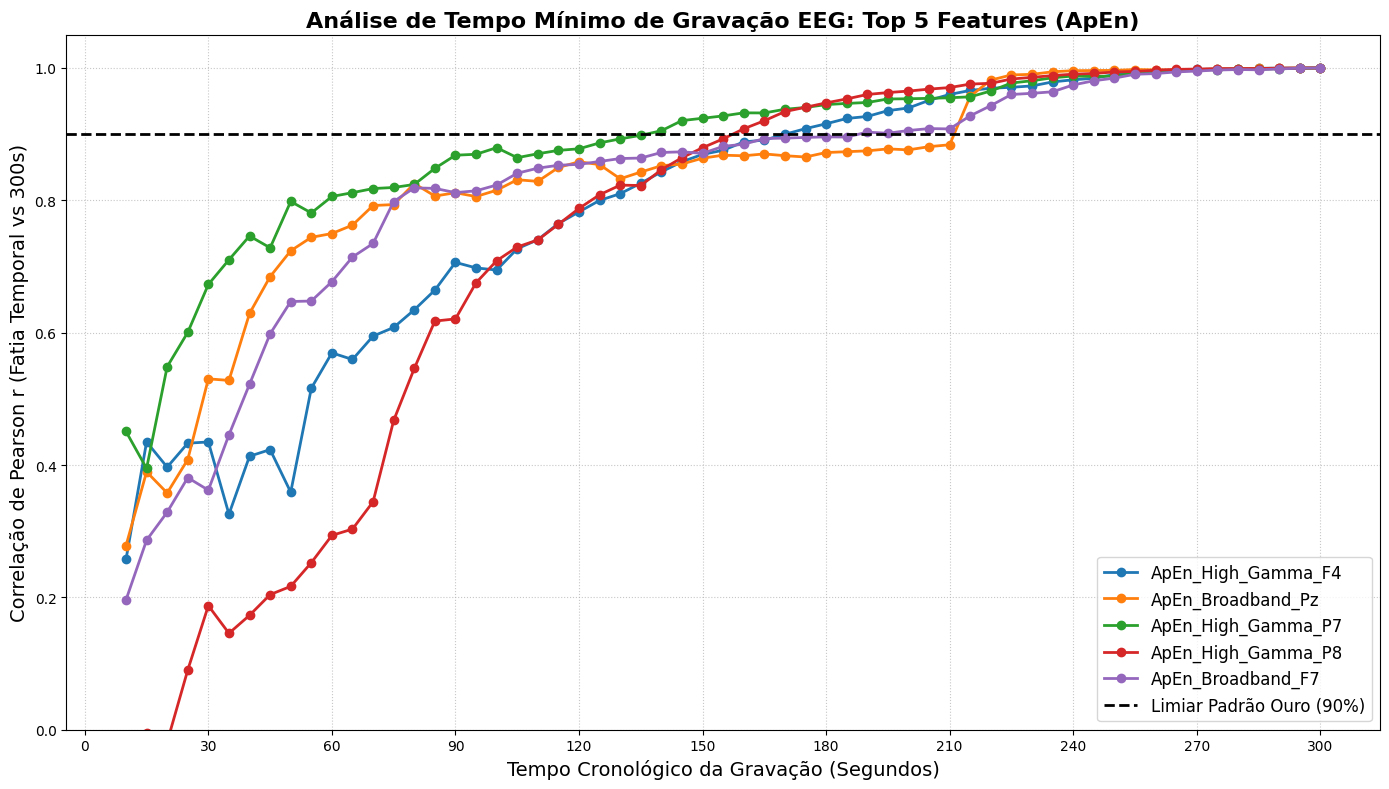

In [13]:
# Top 5 Features do Modelo de Entropia (ApEn)
top_features_entropy = [
    {'name': 'ApEn_High_Gamma_F4', 'channel': 'F4', 'band': 'High_Gamma'},
    {'name': 'ApEn_Broadband_Pz',  'channel': 'Pz', 'band': 'Broadband'},
    {'name': 'ApEn_High_Gamma_P7', 'channel': 'P7', 'band': 'High_Gamma'},
    {'name': 'ApEn_High_Gamma_P8', 'channel': 'P8', 'band': 'High_Gamma'},
    {'name': 'ApEn_Broadband_F7',  'channel': 'F7', 'band': 'Broadband'}
]

bands = {
    'Delta': (0.1, 4), 'Theta': (4, 8), 'Low_Alpha': (8, 10),
    'High_Alpha': (10, 13), 'Low_Beta': (13, 17), 'High_Beta': (18, 30),
    'Low_Gamma': (30, 50), 'High_Gamma': (50, 100)
}

epoch_length_sec = 5
time_steps_sec = np.arange(5, 305, 5)  

def compute_apen(data_epochs_2d):
    """Calcula a Approximate Entropy para o conjunto de épocas de um canal."""
    apen_vals = []
    for ep_idx in range(data_epochs_2d.shape[0]):
        x = data_epochs_2d[ep_idx, :]
        tol = 0.2 * np.std(x)
        if tol == 0:
            continue
        ap = ant.app_entropy(x, order=3, metric='chebyshev', tolerance=tol)
        apen_vals.append(ap)
    return np.mean(apen_vals) if len(apen_vals) > 0 else np.nan

def extract_specific_entropy(epochs_slice, channel, band_name, sfreq):
    """Filtra o sinal e extrai ApEn para o canal alvo."""
    if channel not in epochs_slice.ch_names:
        return np.nan
        
    ch_idx = epochs_slice.ch_names.index(channel)
    channel_epochs = epochs_slice.get_data()[:, ch_idx, :]
    
    if band_name == 'Broadband':
        return compute_apen(channel_epochs)
    else:
        fmin, fmax = bands[band_name]
        filtered_epochs = mne.filter.filter_data(
            channel_epochs, sfreq, l_freq=fmin, h_freq=fmax, verbose=False
        )
        return compute_apen(filtered_epochs)

history_entropy = {feat['name']: {int(float(pid)): {} for pid in df_complete['ID']} for feat in top_features_entropy}

print("Iniciando extração temporal dos Top 5 Biomarcadores de Entropia (ApEn)...")

# Fatiamento Cronológico e Extração do ApEn
for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID']))
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_ec-epo.fif")
    
    if not os.path.exists(path):
        continue
        
    try:
        epochs = mne.read_epochs(path, preload=True, verbose=False)
        chronological_ids = epochs.events[:, 2] 
        sfreq = epochs.info['sfreq']
        
        # Padrão Ouro (Sinal Total 300s)
        for feat in top_features_entropy:
            history_entropy[feat['name']][patient_id]['gold'] = extract_specific_entropy(
                epochs, feat['channel'], feat['band'], sfreq
            )

        # Fatiamento Progressivo
        for t_sec in time_steps_sec:
            max_chronological_id = int(t_sec / epoch_length_sec) - 1
            valid_indices = np.where(chronological_ids <= max_chronological_id)[0]
            epochs_slice = epochs[valid_indices]
            
            if len(epochs_slice) == 0:
                for feat in top_features_entropy:
                    history_entropy[feat['name']][patient_id][t_sec] = np.nan
            else:
                for feat in top_features_entropy:
                    history_entropy[feat['name']][patient_id][t_sec] = extract_specific_entropy(
                        epochs_slice, feat['channel'], feat['band'], sfreq
                    )
                        
    except Exception as e:
        print(f"Aviso no paciente {patient_id}: {e}")

# Cálculo da Correlação e Gráfico de Convergência (Pearson)
plt.figure(figsize=(14, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
threshold = 0.90

for feat, color in zip(top_features_entropy, colors):
    feat_name = feat['name']
    correlations = []
    valid_times = []
    
    valid_patients = [pid for pid, data in history_entropy[feat_name].items() if 'gold' in data and not np.isnan(data['gold'])]
    
    for t_sec in time_steps_sec:
        vals_t = []
        vals_gold = []
        
        for pid in valid_patients:
            val_t = history_entropy[feat_name][pid].get(t_sec, np.nan)
            val_gold = history_entropy[feat_name][pid]['gold']
            
            if not np.isnan(val_t) and not np.isnan(val_gold):
                vals_t.append(val_t)
                vals_gold.append(val_gold)
                
        if len(vals_t) > 10:
            corr, _ = pearsonr(vals_t, vals_gold)
            correlations.append(corr)
            valid_times.append(t_sec)
    
    plt.plot(valid_times, correlations, marker='o', linewidth=2, color=color, label=feat_name)
    
    min_time = next((t for t, c in zip(valid_times, correlations) if c >= threshold), None)
    if min_time:
        print(f"[{feat_name}] Tempo mínimo de estabilidade (>90%): {min_time} segundos.")
    else:
        print(f"[{feat_name}] Não atingiu 90% de estabilidade nos primeiros {max(time_steps_sec)}s.")

plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label='Limiar Padrão Ouro (90%)')

plt.title('Análise de Tempo Mínimo de Gravação EEG: Top 5 Features (ApEn)', fontsize=16, fontweight='bold')
plt.xlabel('Tempo Cronológico da Gravação (Segundos)', fontsize=14)
plt.ylabel('Correlação de Pearson r (Fatia Temporal vs 300s)', fontsize=14)
plt.ylim(0.0, 1.05)
plt.xticks(np.arange(0, 305, 30))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, '05_svm_entropy_time_convergence.png'), dpi=300)
plt.show()